In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator, Statevector
from scipy.linalg import eigh
from numpy import pi, exp, sqrt, real, imag

# ================================== 基本设置 ==================================
N = 2**3
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
dx = 2*pi/N

# ================================== 涡度算符构造 ==================================
def get_vorticity_operators(nx, ny):
    N = 2 ** nx
    delta = 2 * np.pi / N
    dim = 2 * N * N
    obs = []

    def index(ix, iy): return ix * N + iy

    for ix in range(1, N-1):
        for iy in range(1, N-1):
            O = np.zeros((dim, dim), dtype=complex)
            idx_p_x = index(ix+1, iy)
            idx_m_x = index(ix-1, iy)
            idx_p_y = index(ix, iy+1)
            idx_m_y = index(ix, iy-1)

            O[idx_p_x, idx_p_x] += 1j / (2*delta)
            O[idx_m_x, idx_m_x] -= 1j / (2*delta)
            O[idx_p_x+N*N, idx_p_x+N*N] += 1j / (2*delta)
            O[idx_m_x+N*N, idx_m_x+N*N] -= 1j / (2*delta)

            O[idx_m_y, idx_m_y] += 1j / (2*delta)
            O[idx_p_y, idx_p_y] -= 1j / (2*delta)
            O[idx_m_y+N*N, idx_m_y+N*N] += 1j / (2*delta)
            O[idx_p_y+N*N, idx_p_y+N*N] -= 1j / (2*delta)

            obs.append(O)
    return obs, [(ix, iy) for ix in range(1, N-1) for iy in range(1, N-1)]

# ================================== 初始条件 ==================================
x0, y0 = 0, 0
R = np.sqrt((X - x0)**2 + (Y - y0)**2)
sigma = 3
f = exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / sqrt(abs(u)**2 + abs(v)**4)
psi2_0 = v**2 / sqrt(abs(u)**2 + abs(v)**4)
initial_state = np.array([psi1_0, psi2_0]).reshape(-1)
initial_state = initial_state / np.linalg.norm(initial_state)

# ================================== 演化模块 ==================================
def kinetic_operator(n, dt):
    qc = QuantumCircuit(n)
    qc.rz(-2**(n-1)*dt, n-1)
    for i in range(n):
        qc.rz(2**(n-i-2)*dt, n-i-1)
    for i in range(1, n):
        qc.cx(n-1, n-i-1)
        qc.rz(-2**(2*n-i-2)*dt, n-i-1)
        qc.cx(n-1, n-i-1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n-i-1, n-j-1)
                qc.rz(2**(2*n-i-j-4)*dt, n-j-1)
                qc.cx(n-i-1, n-j-1)
    return qc

def evolve(nx, ny, dt, initial_state):
    q_num = nx + ny + 1
    circ = QuantumCircuit(q_num)
    circ.initialize(initial_state)
    circ.barrier()

    from qiskit.circuit.library import QFT
    QFT_x = QFT(nx)
    QFT_y = QFT(ny)
    IQFT_x = QFT(nx).inverse()
    IQFT_y = QFT(ny).inverse()

    kinetic_x = kinetic_operator(nx, dt)
    kinetic_y = kinetic_operator(ny, dt)

    circ.append(QFT_x, range(nx))
    circ.append(QFT_y, range(nx, nx+ny))
    circ.barrier()
    circ.append(kinetic_x, range(nx))
    circ.append(kinetic_y, range(nx, nx+ny))
    circ.barrier()
    circ.append(IQFT_x, range(nx))
    circ.append(IQFT_y, range(nx, nx+ny))
    circ.save_statevector()

    simulator = AerSimulator(method='statevector')
    circ = transpile(circ, simulator)
    result = simulator.run(circ).result()
    return np.array(result.data(0)['statevector'])

# ================================== Shadow 模块 ==================================
def get_expectation(statevec, observables):
    return [np.real(statevec.conj().T @ (O @ statevec)) for O in observables]

def build_shadow_evolution_circuit(H_S, init_expvals, t):
    M = len(init_expvals)
    psi0 = np.array(init_expvals, dtype=complex)
    psi0 /= np.linalg.norm(psi0)
    n_shadow = int(np.ceil(np.log2(M)))
    dim = 2**n_shadow

    init_state = np.zeros(dim, dtype=complex)
    init_state[:M] = psi0

    eigvals, V = eigh(H_S)
    U_s = V @ np.diag(np.exp(-1j * eigvals * t)) @ V.conj().T
    U_pad = np.eye(dim, dtype=complex)
    U_pad[:M, :M] = U_s

    circ = QuantumCircuit(n_shadow)
    circ.initialize(init_state, range(n_shadow))
    circ.append(Operator(U_pad), range(n_shadow))
    circ.save_statevector()
    return circ, n_shadow

def construct_kinetic_H_phys(N):
    k = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(k, k)
    Lap = -(KX**2 + KY**2)
    T = np.diag(Lap.flatten())

    from qiskit.quantum_info import Operator
    from qiskit.circuit.library import QFT
    qft_circ = QFT(int(np.log2(N)), do_swaps=False)
    qft = Operator(qft_circ).data

    qft2d = np.kron(qft, qft)
    iqft2d = qft2d.conj().T

    T_pos = iqft2d @ T @ qft2d

    H_phys = np.zeros((2*N*N, 2*N*N), dtype=complex)
    H_phys[:N*N, :N*N] = T_pos
    H_phys[N*N:, N*N:] = T_pos
    return H_phys

def construct_shadow_HS_commutator(H_phys, observables):
    M = len(observables)
    D = H_phys.shape[0]
    H_S = np.zeros((M, M), dtype=complex)
    for m, Om in enumerate(observables):
        comm = H_phys @ Om - Om @ H_phys
        for n, On in enumerate(observables):
            H_S[m, n] = 1j * np.trace(On.conj().T @ comm) / D
    H_S = (H_S + H_S.conj().T) / 2
    return H_S



In [7]:
# ================================== 主流程：以涡度为可观测量 ==================================
nx = ny = 3
dt = np.pi
observables, all_points = get_vorticity_operators(nx, ny)

state_0 = evolve(nx, ny, 0.0, initial_state)
H_phys = construct_kinetic_H_phys(N)
H_S = construct_shadow_HS_commutator(H_phys, observables)

print("H_S norm =", np.linalg.norm(H_S))
print("H_S (submatrix):\n", H_S[:5, :5])

init_expect = get_expectation(state_0, observables)
shadow_circ, n_shadow = build_shadow_evolution_circuit(H_S, init_expect, t=dt)
sim = AerSimulator(method='statevector')
shadow_circ = transpile(shadow_circ, sim)
result = sim.run(shadow_circ).result()
statevec_shadow = np.array(Statevector(result.data(0)['statevector']))
shadow_expect = np.real(statevec_shadow[:len(observables)]) * np.linalg.norm(init_expect)

state_1 = evolve(nx, ny, dt, initial_state)
full_expect = get_expectation(state_1, observables)

print(f"\n✅ Shadow Hamiltonian Simulation 验证 (t = {dt}):")
for i, pt in enumerate(all_points):
    epsilon = 1e-12
    err = abs(full_expect[i] - shadow_expect[i]) / (abs(full_expect[i]) + epsilon)
    print(f"  网格点 {pt}:  全态 = {full_expect[i]:.6f},  影子 = {shadow_expect[i]:.6f},  相对误差 = {err:.2e}")




H_S norm = 0.0
H_S (submatrix):
 [[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]

✅ Shadow Hamiltonian Simulation 验证 (t = 3.141592653589793):
  网格点 (1, 1):  全态 = 0.000000,  影子 = 0.000000,  相对误差 = 1.73e-06
  网格点 (1, 2):  全态 = 0.000000,  影子 = 0.000000,  相对误差 = 8.67e-07
  网格点 (1, 3):  全态 = 0.000000,  影子 = -0.000000,  相对误差 = 2.17e-06
  网格点 (1, 4):  全态 = 0.000000,  影子 = 0.000000,  相对误差 = 2.17e-07
  网格点 (1, 5):  全态 = 0.000000,  影子 = 0.000000,  相对误差 = 0.00e+00
  网格点 (1, 6):  全态 = 0.000000,  影子 = -0.000000,  相对误差 = 4.34e-07
  网格点 (2, 1):  全态 = 0.000000,  影子 = 0.000000,  相对误差 = 0.00e+00
  网格点 (2, 2):  全态 = 0.000000,  影子 = 0.000000,  相对误差 = 0.00e+00
  网格点 (2, 3):  全态 = 0.000000,  影子 = 0.000000,  相对误差 = 1.73e-06
  网格点 (2, 4):  全态 = 0.000000,  影子 = 0.000000,  相对误差 = 8.67e-07
  网格点 (2, 5):  全态 = -0.000000,  影子 = 0.000000,  相对误差 = 4.34e-07
  网格点 (2, 6):  全态 =

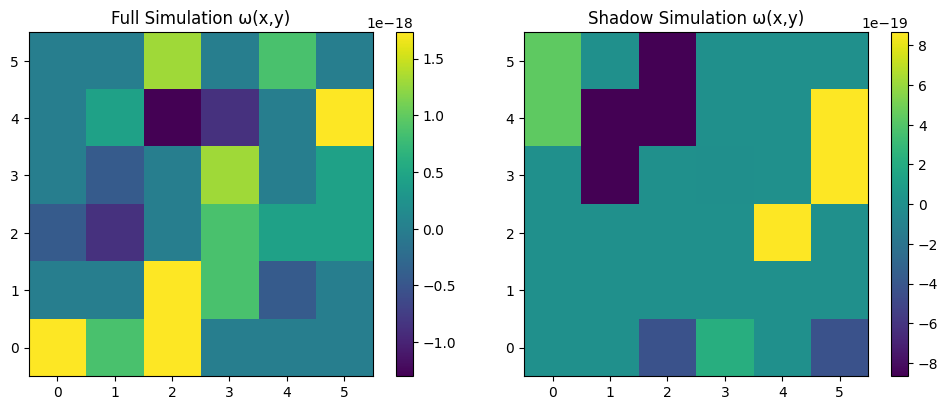

In [8]:
full_map = np.array(full_expect).reshape(N-2, N-2)
shadow_map = np.array(shadow_expect).reshape(N-2, N-2)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im0 = axs[0].imshow(full_map, origin='lower', cmap='viridis')
axs[0].set_title("Full Simulation ω(x,y)")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(shadow_map, origin='lower', cmap='viridis')
axs[1].set_title("Shadow Simulation ω(x,y)")
plt.colorbar(im1, ax=axs[1])
plt.tight_layout()
plt.show()